In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

lambd = 0.5     # Vitesse à laquelle la forêt repousse vers l
l = 100.0       # quantité max de bois possible
sigma_val = 5.0     # Force des événements imprévisibles
x0 = 10.0       # Quantité de bois présente à l'instant 0


h = 0.01        # pas de temps
k = 10.0        # Frais fixes à chaque coupe
p = 1.0         # Prix de vente d'une unité de bois sur le marché

In [ ]:
def b(x, modele_b='1'):
    if modele_b == '1':
        return lambd * (l - x)
    elif modele_b == '2':
        return lambd * x * (l - x)

def sigma(x, modele_sigma='a'):
    if modele_sigma == 'a':
        return sigma_val
    elif modele_sigma == 'b':
        return sigma_val * np.sqrt(np.abs(x))

def calculer_prochain_pas(x, h, modele_b='1', modele_sigma='a'):
    derive = b(x, modele_b) * h
    bruit = np.random.normal(0, 1)
    diffusion = sigma(x, modele_sigma) * np.sqrt(h) * bruit

    x_suivant = x + derive + diffusion

    return max(x_suivant, 0)

In [ ]:
def simuler_trajectoire(n_pas, h, modele_b='1', modele_sigma='a'):
    x = np.zeros(n_pas + 1)
    x[0] = x0

    for i in range(n_pas):
        x[i+1] = calculer_prochain_pas(x[i], h, modele_b, modele_sigma)

    return x

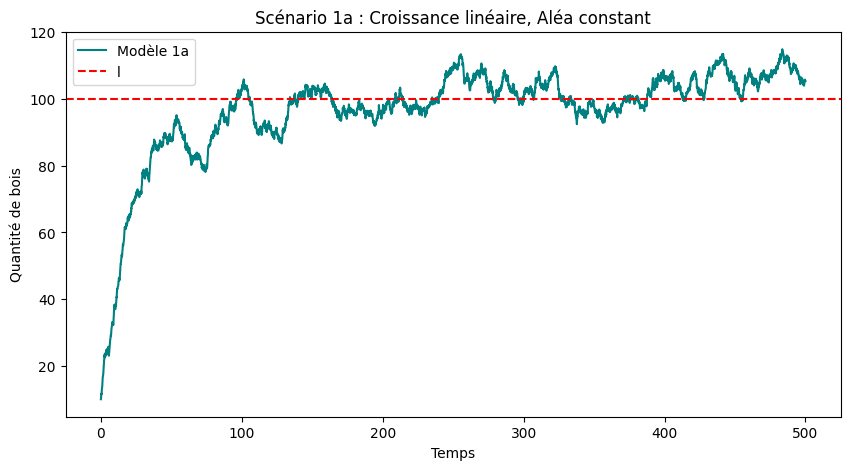

In [ ]:
n_pas = 5000
temps = np.linspace(0, n_pas * h, n_pas + 1)*10

x_1a = simuler_trajectoire(n_pas, h, modele_b='1', modele_sigma='a')

plt.figure(figsize=(10, 5))
plt.plot(temps, x_1a, color='teal', label="Modèle 1a")
plt.axhline(l, color='red', linestyle='--', label="l")
plt.title("Scénario 1a : Croissance linéaire, Aléa constant")
plt.xlabel("Temps")
plt.ylabel("Quantité de bois")
plt.legend()
plt.show()

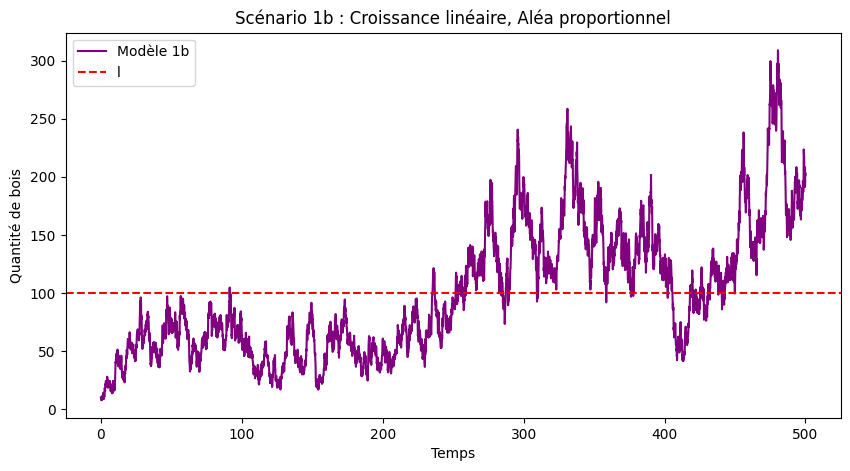

In [ ]:
x_1b = simuler_trajectoire(n_pas, h, modele_b='1', modele_sigma='b')

plt.figure(figsize=(10, 5))
plt.plot(temps, x_1b, color='purple', label="Modèle 1b")
plt.axhline(l, color='red', linestyle='--', label="l")
plt.title("Scénario 1b : Croissance linéaire, Aléa proportionnel")
plt.xlabel("Temps")
plt.ylabel("Quantité de bois")
plt.legend()
plt.show()

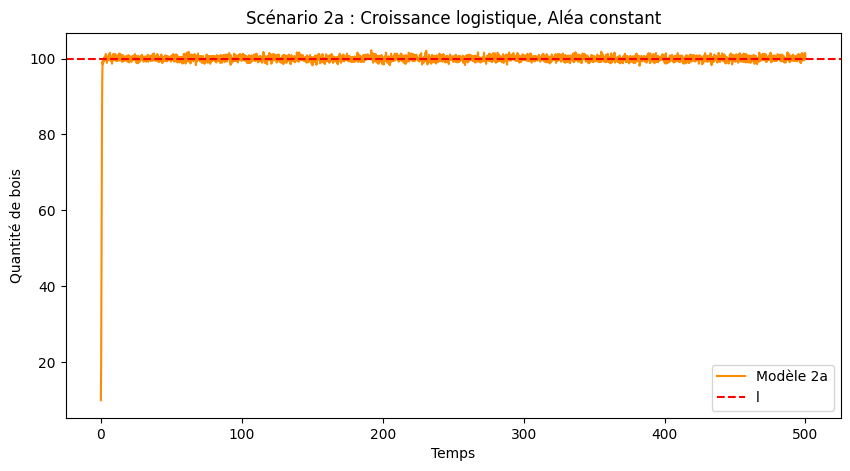

In [ ]:
x_2a = simuler_trajectoire(n_pas, h, modele_b='2', modele_sigma='a')

plt.figure(figsize=(10, 5))
plt.plot(temps, x_2a, color='darkorange', label="Modèle 2a")
plt.axhline(l, color='red', linestyle='--', label="l")
plt.title("Scénario 2a : Croissance logistique, Aléa constant")
plt.xlabel("Temps")
plt.ylabel("Quantité de bois")
plt.legend()
plt.show()

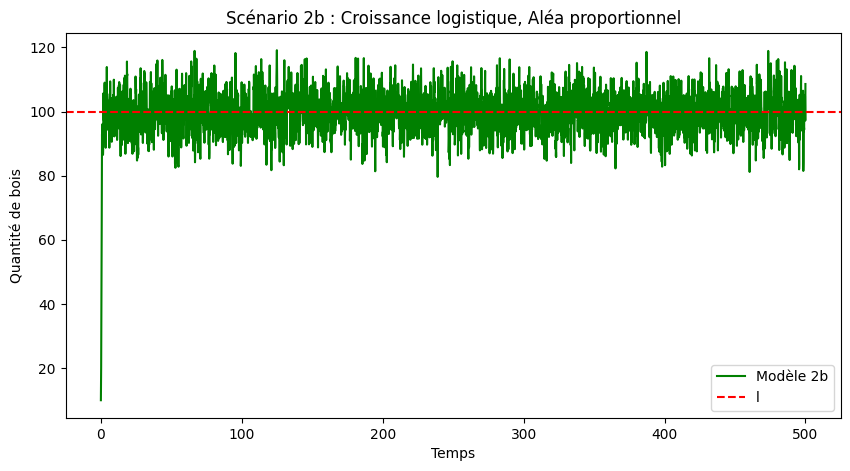

In [ ]:
x_2b = simuler_trajectoire(n_pas, h, modele_b='2', modele_sigma='b')

plt.figure(figsize=(10, 5))
plt.plot(temps, x_2b, color='green', label="Modèle 2b")
plt.axhline(l, color='red', linestyle='--', label="l")
plt.title("Scénario 2b : Croissance logistique, Aléa proportionnel")
plt.xlabel("Temps")
plt.ylabel("Quantité de bois")
plt.legend()
plt.show()

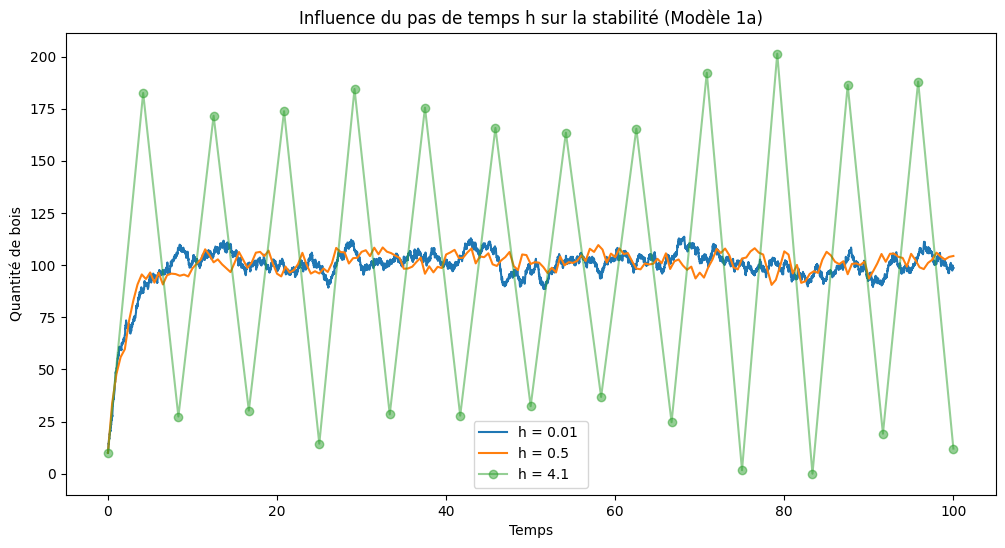

In [ ]:
h_petit = 0.01
h_moyen = 0.5
h_grand = 3.0
# Avec h < 2/lambda
h_suplambda = 4.1

temps_simulation_max = 100

n_pas_petit = int(temps_simulation_max / h_petit)
n_pas_moyen = int(temps_simulation_max / h_moyen)
n_pas_grand = int(temps_simulation_max / h_grand)
n_pas_suplambda = int(temps_simulation_max / h_suplambda)

x_petit = simuler_trajectoire(n_pas_petit, h_petit, '1', 'a')
x_moyen = simuler_trajectoire(n_pas_moyen, h_moyen, '1', 'a')
x_grand = simuler_trajectoire(n_pas_grand, h_grand, '1', 'a')
x_suplambda = simuler_trajectoire(n_pas_suplambda, h_suplambda, '1', 'a')


plt.figure(figsize=(12, 6))
plt.plot(np.linspace(0, temps_simulation_max, n_pas_petit + 1), x_petit, label=f"h = {h_petit} ")
plt.plot(np.linspace(0, temps_simulation_max, n_pas_moyen + 1), x_moyen, label=f"h = {h_moyen} ")
# plt.plot(np.linspace(0, temps_simulation_max, n_pas_grand + 1), x_grand, label=f"h = {h_grand} ", marker='o', alpha=0.5)
plt.plot(np.linspace(0, temps_simulation_max, n_pas_suplambda + 1), x_suplambda, label=f"h = {h_suplambda} ", marker='o', alpha=0.5)


plt.title("Influence du pas de temps h sur la stabilité (Modèle 1a)")
plt.xlabel("Temps")
plt.ylabel("Quantité de bois")
plt.legend()
plt.show()

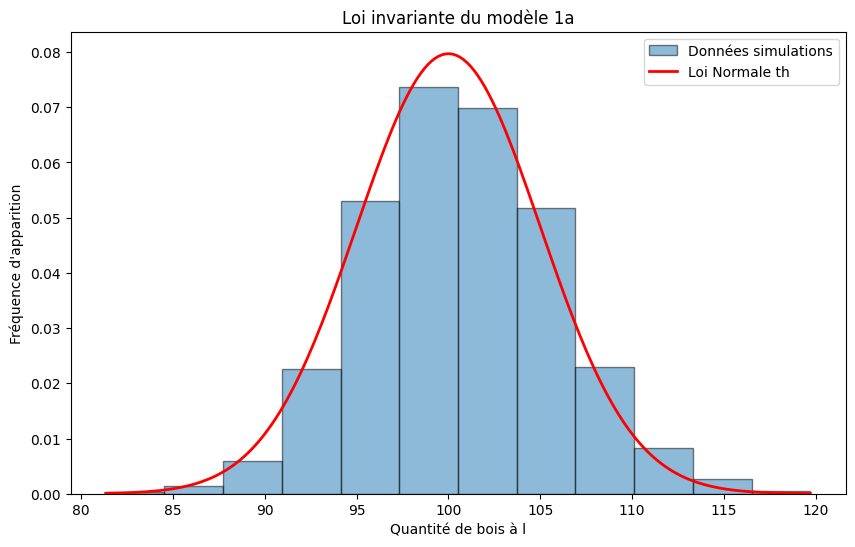

In [ ]:
n_pas_long = 100000
x_long = simuler_trajectoire(n_pas_long, h, '1', 'a')

x_equilibre = x_long[20000:]

variance_th = (sigma_val**2) / (2 * lambd - (lambd**2) * h) # Voir résolution Analytique
ecart_type_th = np.sqrt(variance_th)

plt.figure(figsize=(10, 6))

plt.hist(x_equilibre, bins=12, density=True, alpha=0.5, label="Données simulations", edgecolor = "black")

x_th = np.linspace(min(x_equilibre), max(x_equilibre), 200)
y_th = stats.norm.pdf(x_th, loc=l, scale=ecart_type_th)
plt.plot(x_th, y_th, 'r-', lw=2, label="Loi Normale th")

plt.title("Loi invariante du modèle 1a")
plt.xlabel("Quantité de bois à l")
plt.ylabel("Fréquence d'apparition")
plt.legend()
plt.show()

In [ ]:
# Évaluation d'un seuil de coupe spécifique y
# Attention, prends un peu de temps selon la machine (max 15 secondes je pense)
def evaluer_profit(y, modele_b='1', modele_sigma='a', n_pas=50000):
    x = x0
    profit = 0.0
    for _ in range(n_pas):
        if x >= y:
            profit += p * x - k  # On vend le bois et on paie les frais fixes
            x = 0.0              # La forêt est coupée

        x = calculer_prochain_pas(x, h, modele_b, modele_sigma)

    return profit / (n_pas * h)  # Profit moyen par unité de temps

# plage de seuils
seuils = np.linspace(15, 150, 40)

profits1a = [evaluer_profit(y) for y in seuils]
profits1b = [evaluer_profit(y,'1','b') for y in seuils]
profits2a = [evaluer_profit(y,'2','a') for y in seuils]
profits2b = [evaluer_profit(y,'2','b') for y in seuils]

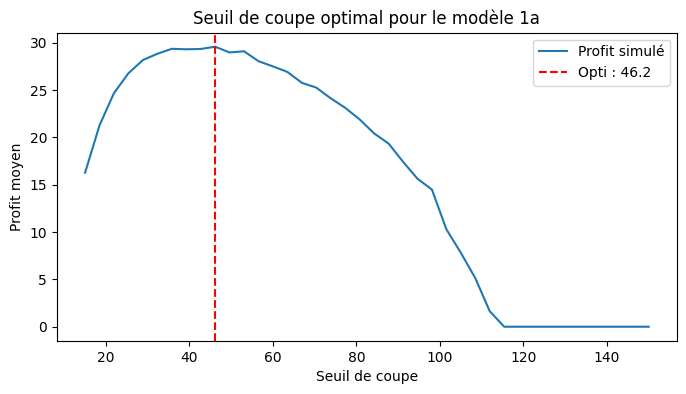

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(seuils, profits1a, label="Profit simulé")


posmax1a = np.argmax(profits1a)
plt.axvline(seuils[posmax1a], color='red', linestyle='--', label=f"Opti : {seuils[posmax1a]:.1f}")

plt.xlabel("Seuil de coupe")
plt.ylabel("Profit moyen")
plt.title("Seuil de coupe optimal pour le modèle 1a")
plt.legend()
plt.show()

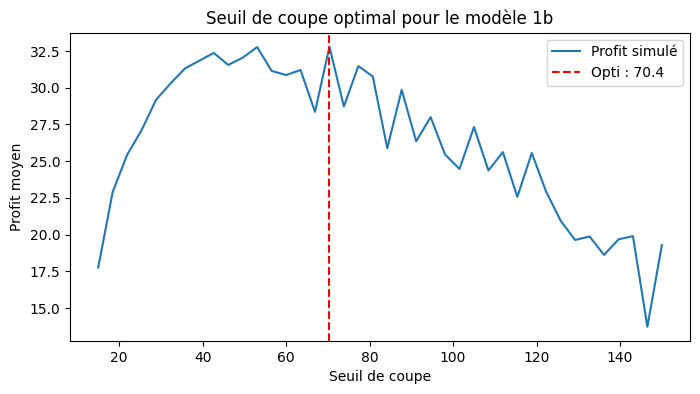

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(seuils, profits1b, label="Profit simulé")


posmax1b = np.argmax(profits1b)
plt.axvline(seuils[posmax1b], color='red', linestyle='--', label=f"Opti : {seuils[posmax1b]:.1f}")

plt.xlabel("Seuil de coupe")
plt.ylabel("Profit moyen")
plt.title("Seuil de coupe optimal pour le modèle 1b")
plt.legend()
plt.show()

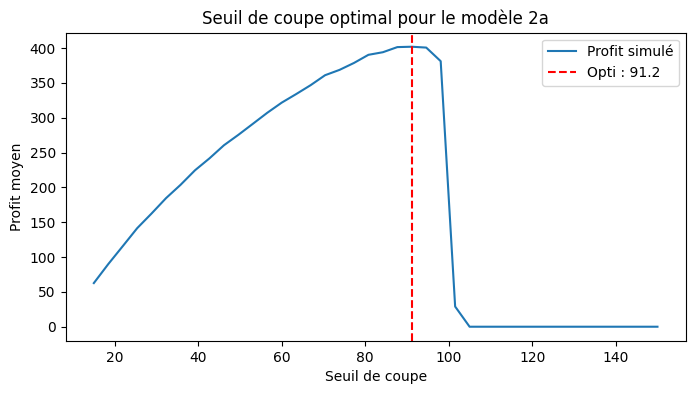

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(seuils, profits2a, label="Profit simulé")


posmax2a = np.argmax(profits2a)
plt.axvline(seuils[posmax2a], color='red', linestyle='--', label=f"Opti : {seuils[posmax2a]:.1f}")

plt.xlabel("Seuil de coupe")
plt.ylabel("Profit moyen")
plt.title("Seuil de coupe optimal pour le modèle 2a")
plt.legend()
plt.show()

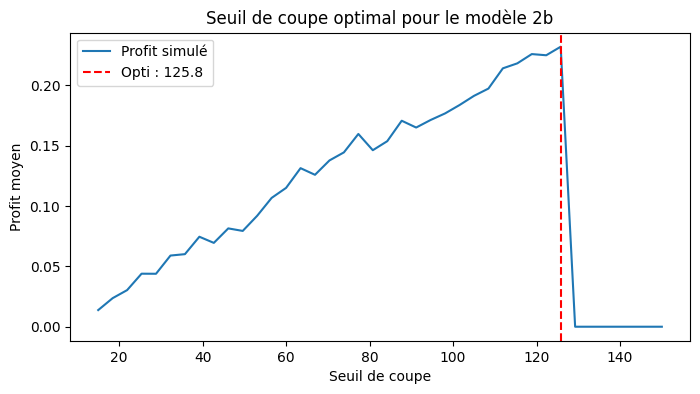

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(seuils, profits2b, label="Profit simulé")


posmax2b = np.argmax(profits2b)
plt.axvline(seuils[posmax2b], color='red', linestyle='--', label=f"Opti : {seuils[posmax2b]:.1f}")

plt.xlabel("Seuil de coupe")
plt.ylabel("Profit moyen")
plt.title("Seuil de coupe optimal pour le modèle 2b")
plt.legend()
plt.show()

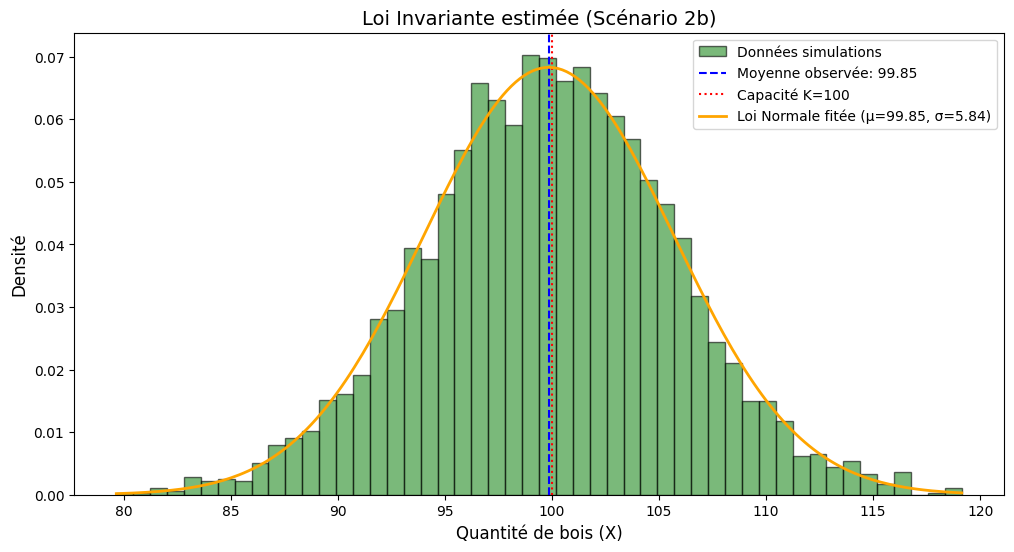

In [ ]:
# 1. On s'assure d'avoir le vecteur temps correspondant à x_2b
# La simulation va de 0 à 50 avec un pas de 0.01
t_recu = np.linspace(0, 50, len(x_2b))

# 2. Définition du point d'équilibre (on ignore le début)
t_debut_equilibre = 5
indices_equilibre = t_recu > t_debut_equilibre
donnees_invariantes = x_2b[indices_equilibre]

# 3. Création de l'affichage
plt.figure(figsize=(12, 6))

# Histogramme
plt.hist(donnees_invariantes, bins=50, density=True, color='forestgreen', alpha=0.6, edgecolor='black', label="Données simulations")

# Indicateurs
moyenne_obs = np.mean(donnees_invariantes)
ecart_type_obs = np.std(donnees_invariantes)
plt.axvline(moyenne_obs, color='blue', linestyle='--', label=f'Moyenne observée: {moyenne_obs:.2f}')
plt.axvline(100, color='red', linestyle=':', label='Capacité K=100')

# Ajout de la courbe de loi normale
x_normal = np.linspace(min(donnees_invariantes), max(donnees_invariantes), 200)
y_normal = stats.norm.pdf(x_normal, loc=moyenne_obs, scale=ecart_type_obs)
plt.plot(x_normal, y_normal, 'orange', lw=2, label=f'Loi Normale fitée (μ={moyenne_obs:.2f}, σ={ecart_type_obs:.2f})')

plt.title("Loi Invariante estimée (Scénario 2b)", fontsize=14)
plt.xlabel("Quantité de bois (X)", fontsize=12)
plt.ylabel("Densité", fontsize=12)
plt.legend()
plt.show()

autre testes avec les modèles 1a 1b et 2a

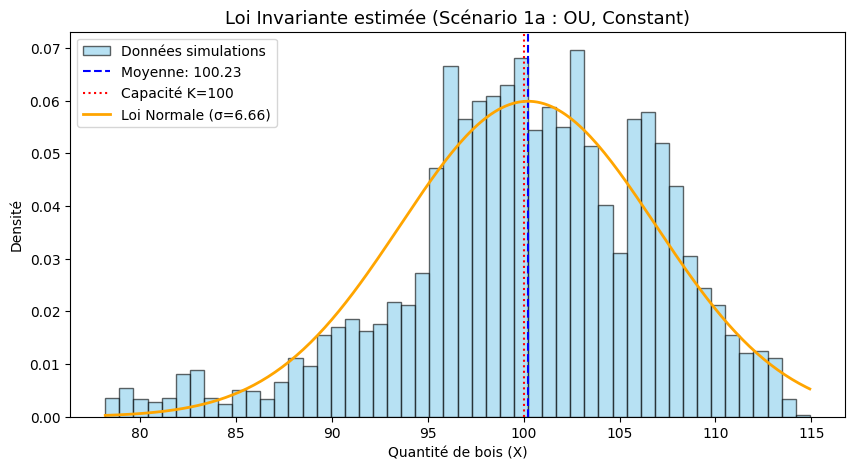

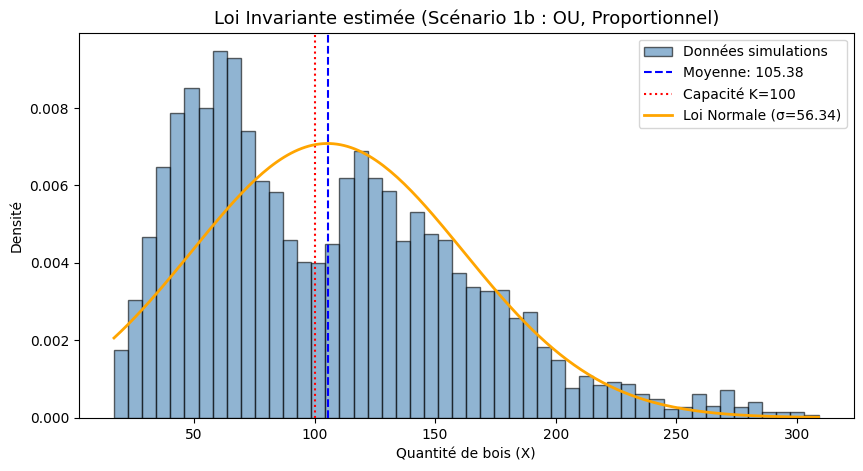

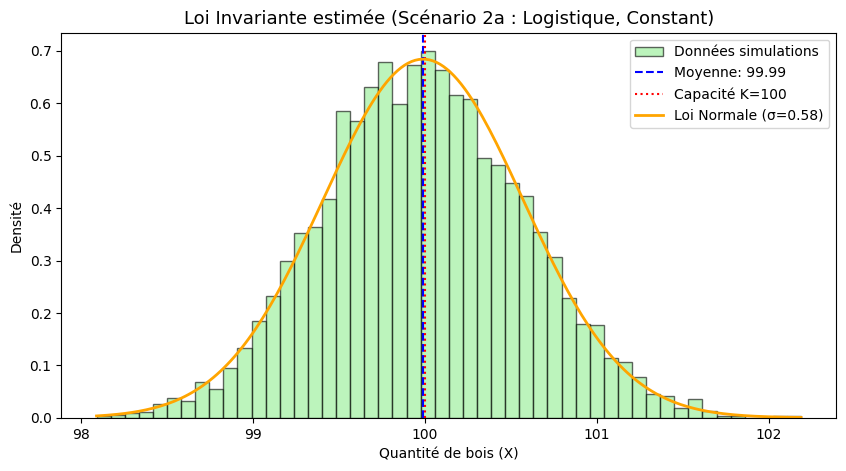

In [ ]:
# On définit le temps (commun à toutes les simulations normalement)
t_recu = np.linspace(0, 50, 5001) # Ajustez 5001 si len(votre_x) est différent
t_debut_equilibre = 5
indices_equilibre = t_recu > t_debut_equilibre

def tracer_histogramme(data, titre, couleur, K=100):
    donnees = data[indices_equilibre]

    plt.figure(figsize=(10, 5))

    # Histogramme
    plt.hist(donnees, bins=50, density=True, color=couleur, alpha=0.6, edgecolor='black', label="Données simulations")

    # Indicateurs
    moyenne_obs = np.mean(donnees)
    ecart_type_obs = np.std(donnees)
    plt.axvline(moyenne_obs, color='blue', linestyle='--', label=f'Moyenne: {moyenne_obs:.2f}')
    plt.axvline(K, color='red', linestyle=':', label=f'Capacité K={K}')

    # Loi normale fitée
    x_normal = np.linspace(min(donnees), max(donnees), 200)
    y_normal = stats.norm.pdf(x_normal, loc=moyenne_obs, scale=ecart_type_obs)
    plt.plot(x_normal, y_normal, 'orange', lw=2, label=f'Loi Normale (σ={ecart_type_obs:.2f})')

    plt.title(titre, fontsize=13)
    plt.xlabel("Quantité de bois (X)")
    plt.ylabel("Densité")
    plt.legend()
    plt.show()

# --- Exécution pour les 3 scénarios ---

# Scénario 1a : Modèle de retour à la moyenne (OU), Aléa constant
tracer_histogramme(x_1a, "Loi Invariante estimée (Scénario 1a : OU, Constant)", "skyblue")

# Scénario 1b : Modèle de retour à la moyenne (OU), Aléa proportionnel
tracer_histogramme(x_1b, "Loi Invariante estimée (Scénario 1b : OU, Proportionnel)", "steelblue")

# Scénario 2a : Croissance logistique, Aléa constant
tracer_histogramme(x_2a, "Loi Invariante estimée (Scénario 2a : Logistique, Constant)", "lightgreen")